# SarcGraph Tutorial

All demos are availble on GitHub at https://github.com/Sarc-Graph/sarcgraph/tree/main/tutorials.

To run demos with `jupyter notebook` check [Installation Guide](https://sarc-graph.readthedocs.io/en/latest/installation.html).

SarcGraph incorporates functions to automatically detect and track z-discs and sarcomeres in movies of beating **human induced pluripotent stem cell-derived cardiomyocytes (hiPSC-CMs)**. In addition, SarcGraph includes the tools which enable the recovery of basic sarcomere characteristics and the ability to run further high level analysis.

In this notebook we provide a tutorial on how to use the SarcGraph package using demos and examples. The focus if on the ``SarcGraph`` class in the ``sarcgraph.sg`` module.

## SarcGraph on a Sample Video

In this section we show how to use ``SarcGraph`` to detect and track z-discs and sarcomeres in a sample movie of beating hiPSC-CM. 

To showcase this we use ``samples/sample_0.avi``.

### Import Modules

The first step is to import ``SarcGraph`` class from ``sarcgraph`` module:

<div style="background-color: #ffcccc; padding: 10px; border-radius: 5px; color: black;">
    <strong>Note:</strong> If you are accessing this tutorial through Binder, please uncomment and run this cell.
</div>

In [ ]:
# !pip install -e ../.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sarcgraph import SarcGraph

### SarcGraph Initialization

Next, we need to create an instance of the `SarcGraph` class.

After creating the instance, you will see a printed list of all configurable option variables.  
You can change them using either of the two methods below:

```python
sg.config.sigma = 2.0
sg._update_config(sigma=2.0)

In [7]:
sg = SarcGraph()

output_dir = output
input_type = video
save_output = True
sigma = 1.0
zdisc_min_length = 10
zdisc_max_length = 100
full_track_ratio = 0.75
tp_depth = 4
skip_merge = False
num_neighbors = 3
avg_sarc_length = 15.0
min_sarc_length = 0.0
max_sarc_length = 30.0
coeff_avg_length = 1.0
coeff_neighbor_length = 1.0
coeff_neighbor_angle = 1.0
score_threshold = 0.1
angle_threshold = 1.2


In [8]:
print("Original sigma:", sg.config.sigma)

sg.config.sigma = 2.0
print("Updated sigma (via direct assignment):", sg.config.sigma)

sg._update_config(sigma=3.0)
print("Updated sigma (via _update_config):", sg.config.sigma)

Original sigma: 1.0
Updated sigma (via direct assignment): 2.0
Updated sigma (via _update_config): 3.0


### Run Detection

The simplest way to perform sarcomere detection on the video sample is to run ``SarcGraph().sarcomere_detection`` function:

In [10]:
sarcomeres, _ = sg.sarcomere_detection(input_file='../samples/sample_0.avi', input_type='video', sigma=1.0)

Frame 79: 81 trajectories present.


<div style="background-color: #ffcccc; padding: 10px; border-radius: 5px; color: black;">
  <strong>Note:</strong> Any keyword argument passed to a function like <code>sarcomere_detection</code> (e.g., <code>sigma=2.0</code>) is internally forwarded to <code>sg._update_config(...)</code> before the function runs. This lets you override config values without manually changing <code>sg.config</code>.
</div>

``SarcGraph().sarcomere_detection`` automatically runs in three steps:

1) Z-disc segmentation: load the video, filter frames, and detect z-discs
2) Z-disc tracking: track detected z-discs
3) Sarcomere detection: detect sarcomeres using tracked z-discs information

And, this is how the output looks like:

**Note**

`sarcomeres.sample(5)` randomly picks 5 samples to display, and running the cell 
multiple times should output different results.

In [11]:
sarcomeres.sample(5)

,frame,sarc_id,x,y,length,width,angle,zdiscs
3529,9,44,122.827395,93.097301,19.091258,13.243788,0.633543,"43,63"
1494,54,18,202.852530,100.594535,21.386733,13.067663,0.585633,"11,15"
3543,23,44,119.437507,88.133541,20.331353,14.011109,0.642878,"43,63"
2616,56,32,274.940081,221.315493,12.413677,14.261831,1.663814,"27,31"
2693,53,33,276.983419,165.536505,12.977938,12.943811,1.812994,"28,32"


By dafault ``save_output=True`` in ``sg.config`` and the following information will be saved in ``sg.config.output_dir``:

- raw video frames (grayscale)
- filtered video frames
- zdisc contours
- segmented zdiscs information
- tracked zdiscs information
- detected sarcomeres information

### Simple Visualization

We briefly show how to use the saved information to visualize z-discs and sarcomeres in one frame of the video.

In [15]:
# load the information
output_dir = sg.config.output_dir
raw_frame = np.load(f"{output_dir}/raw_frames.npy")
tracked_zdiscs = pd.read_csv(f"{output_dir}/tracked_zdiscs.csv", index_col=[0])

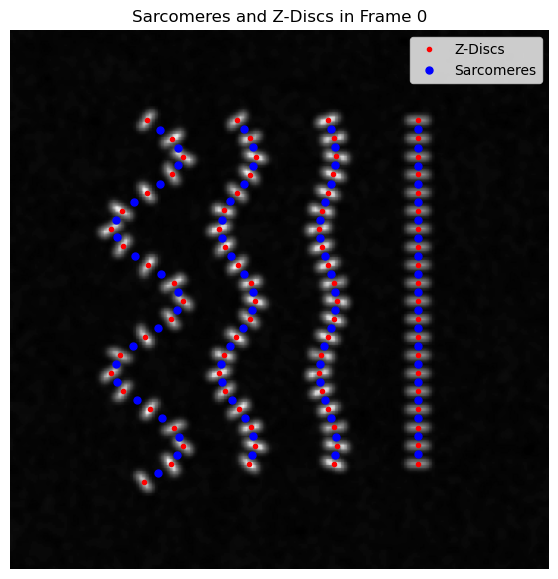

In [18]:
frame_num = 0
sarcs_frame = sarcomeres[sarcomeres.frame == frame_num]
zdiscs_frame = tracked_zdiscs[tracked_zdiscs.frame == frame_num]

plt.figure(figsize=(7,7))
plt.axes().set_title(f'Sarcomeres and Z-Discs in Frame {frame_num}')
plt.axis('off')
plt.imshow(raw_frame[frame_num], cmap='gray')
plt.plot(zdiscs_frame.y, zdiscs_frame.x, 'r.', label='Z-Discs')
plt.plot(sarcs_frame.y, sarcs_frame.x, 'b.', ms=10, label='Sarcomeres')
plt.legend()

### Alternative Way to Run SarcGraph

As mentioned in section [Run Detection](###Run-Detection), ``sg.sarcomere_detection`` performs three tasks consecutively. Each task can also be run separately. Note that the results will not be saved since we have set ``save_output=False``. We show how this can be done below:

#### Z-disc Segmentation

Run ``sg.zdisc_segmentation()``.

- Input could be either ``input_file`` or ``raw_frames``.

**Notes**

- SarcGraph uses ``scikit`` library to load video/image files and can handle most formats. Yet, we recommend loading your sample video/image into a numpy array and pass the array as the input to ``SarcGraph`` functions, especially if the video/image is saved as a ``TIFF`` file.

In [ ]:
zdiscs = sg.zdisc_segmentation(input_file='../samples/sample_0.avi', save_output=False)

# load `raw_frames`
# zdiscs = sg.zdisc_segmentation(raw_frames=raw_frame)

#### Z-disc Tracking

Run ``sg.zdisc_tracking()``.

- If the input is either ``input_file`` or ``raw_frames``, this function runs ``sg.zdisc_segmentation`` first and then applies tracking.
- If the input is ``segmented_zdiscs``, ``sg.zdisc_tracking`` only runs tracking.

In [21]:
tracked_zdiscs = sg.zdisc_tracking(segmented_zdiscs=zdiscs)

Frame 79: 81 trajectories present.


Let's check the information stored in tracked_zdiscs:

In [22]:
tracked_zdiscs.sample(10)

,frame,x,y,p1_x,p1_y,p2_x,p2_y,particle,freq
1555,19,184.518660,266.525160,184.000000,260.667142,185.000000,272.718936,16,80
6429,79,184.506730,167.002881,182.000000,161.092676,187.000000,172.969227,39,80
2867,35,240.177834,150.183357,244.342161,146.000000,236.405462,155.000000,18,80
4018,49,111.995258,155.041922,108.000000,149.557462,115.000000,161.673055,42,80
4072,50,184.520292,277.996214,185.000000,270.838921,184.000000,285.085043,16,80
4251,52,270.681829,163.988891,273.000000,157.839894,269.000000,170.084687,32,80
3189,39,268.891087,263.511588,269.000000,256.284766,269.000000,270.835488,26,80
1480,18,184.714017,169.777278,182.000000,164.528144,187.000000,175.127891,39,80
2924,36,227.753694,148.106487,230.000000,142.209049,226.000000,153.472227,2,80
787,9,72.580198,100.578969,78.000000,96.474222,67.000000,104.803693,0,80


#### Sarcomere Detection Step

Run ``sg.sarcomere_detection()``.

- If the input is either ``input_file`` or ``raw_frames``, this function runs ``sg.zdisc_segmentation`` then ``sg.zdisc_tracking`` before applying sarcomere detection.
- If the input is ``segmented_zdiscs``, this function runs ``sg.zdisc_tracking`` first and then sarcomere detection.
- If the input is ``tracked_zdiscs``, this function only runs sarcomere detection.

In [26]:
sarcs, _ = sg.sarcomere_detection(tracked_zdiscs=tracked_zdiscs)

## SarcGraph on a Sample Image

To analyze a single frame, we can follow the same steps with a few modifications:

- When working on single-frame images instead of videos, tracking cannot be performed. Therefore, during [SarcGraph Initialization](###-SarcGraph-Initialization), we should set `input_type="image"`.
- If, instead of running `SarcGraph().sarcomere_detection` with `input_file` or `raw_frames`, you want to process the image step-by-step, you should still run `SarcGraph().zdiscs_tracking` or pass `segmented_zdiscs` into `sarcomere_detection`, even though tracking won't be applied on still image.


Import ``SarcGraph`` class first:

In [27]:
from sarcgraph import SarcGraph

Create a new instance of ``SarcGraph`` class and set ``input_type='image'``

In [29]:
sg_img = SarcGraph(output_dir='../tutorial-results-image', input_type='image')

output_dir = ../tutorial-results-image
input_type = image
save_output = True
sigma = 1.0
zdisc_min_length = 10
zdisc_max_length = 100
full_track_ratio = 0.75
tp_depth = 4
skip_merge = False
num_neighbors = 3
avg_sarc_length = 15.0
min_sarc_length = 0.0
max_sarc_length = 30.0
coeff_avg_length = 1.0
coeff_neighbor_length = 1.0
coeff_neighbor_angle = 1.0
score_threshold = 0.1
angle_threshold = 1.2


Let's load a sample image to a numpy array and pass it to ``sg_img.sarcomere_detection()`` rather than specifying ``input_file``:

**Note**

We used ``matplotlib.image`` to load the image here.

In [44]:
import matplotlib

img = matplotlib.image.imread('../samples/sample_5.png')

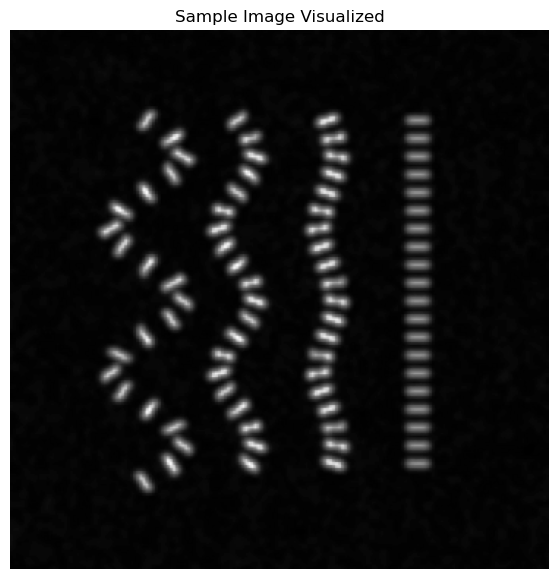

In [45]:
plt.figure(figsize=(7,7)) 
plt.axes().set_title('Sample Image Visualized')
plt.axis('off')
plt.imshow(img, cmap='gray')

Now we can run ``sg_img.sarcomere_detection()``:

In [46]:
# Image must be a stack of 2D images even if it is a single image.
img = img[None, :, :]
sarcs_img, _ = sg_img.sarcomere_detection(raw_frames=img)

Similar to the video sample, we will visualize detected sarcomeres in this image:

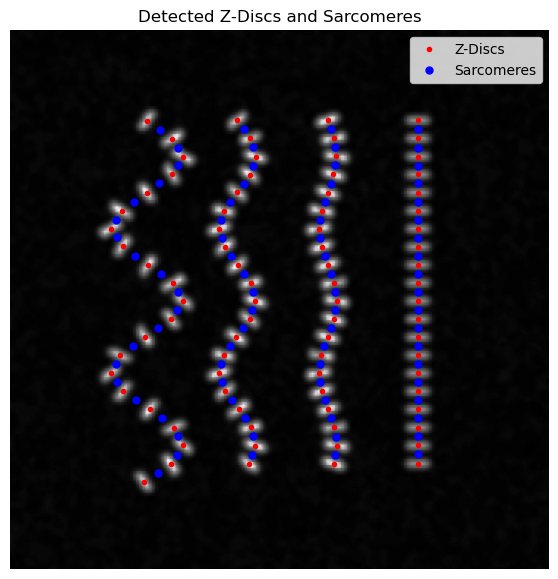

In [52]:
output_dir = sg_img.config.output_dir

segmented_zdiscs = pd.read_csv(f"{output_dir}/segmented_zdiscs.csv", index_col=[0])

plt.figure(figsize=(7,7))
plt.axes().set_title('Detected Z-Discs and Sarcomeres')
plt.axis('off')
plt.imshow(img[0], cmap='gray')
plt.plot(segmented_zdiscs.y, segmented_zdiscs.x, 'r.', label='Z-Discs')
plt.plot(sarcs_img.y, sarcs_img.x, 'b.', ms=10, label='Sarcomeres')
plt.legend()